[Text(0.5, 0.875, 'Sex_female <= 0.5\nentropy = 0.953\nsamples = 596\nvalue = [374, 222]'),
 Text(0.2, 0.625, 'Age <= 3.5\nentropy = 0.696\nsamples = 390\nvalue = [317, 73]'),
 Text(0.1, 0.375, 'entropy = 0.779\nsamples = 13\nvalue = [3, 10]'),
 Text(0.3, 0.375, 'Fare <= 52.277\nentropy = 0.651\nsamples = 377\nvalue = [314, 63]'),
 Text(0.2, 0.125, 'entropy = 0.58\nsamples = 332\nvalue = [286, 46]'),
 Text(0.4, 0.125, 'entropy = 0.956\nsamples = 45\nvalue = [28, 17]'),
 Text(0.8, 0.625, 'Pclass <= 2.5\nentropy = 0.851\nsamples = 206\nvalue = [57, 149]'),
 Text(0.7, 0.375, 'Fare <= 149.035\nentropy = 0.23\nsamples = 107\nvalue = [4, 103]'),
 Text(0.6, 0.125, 'entropy = 0.149\nsamples = 94\nvalue = [2, 92]'),
 Text(0.8, 0.125, 'entropy = 0.619\nsamples = 13\nvalue = [2, 11]'),
 Text(0.9, 0.375, 'entropy = 0.996\nsamples = 99\nvalue = [53, 46]')]

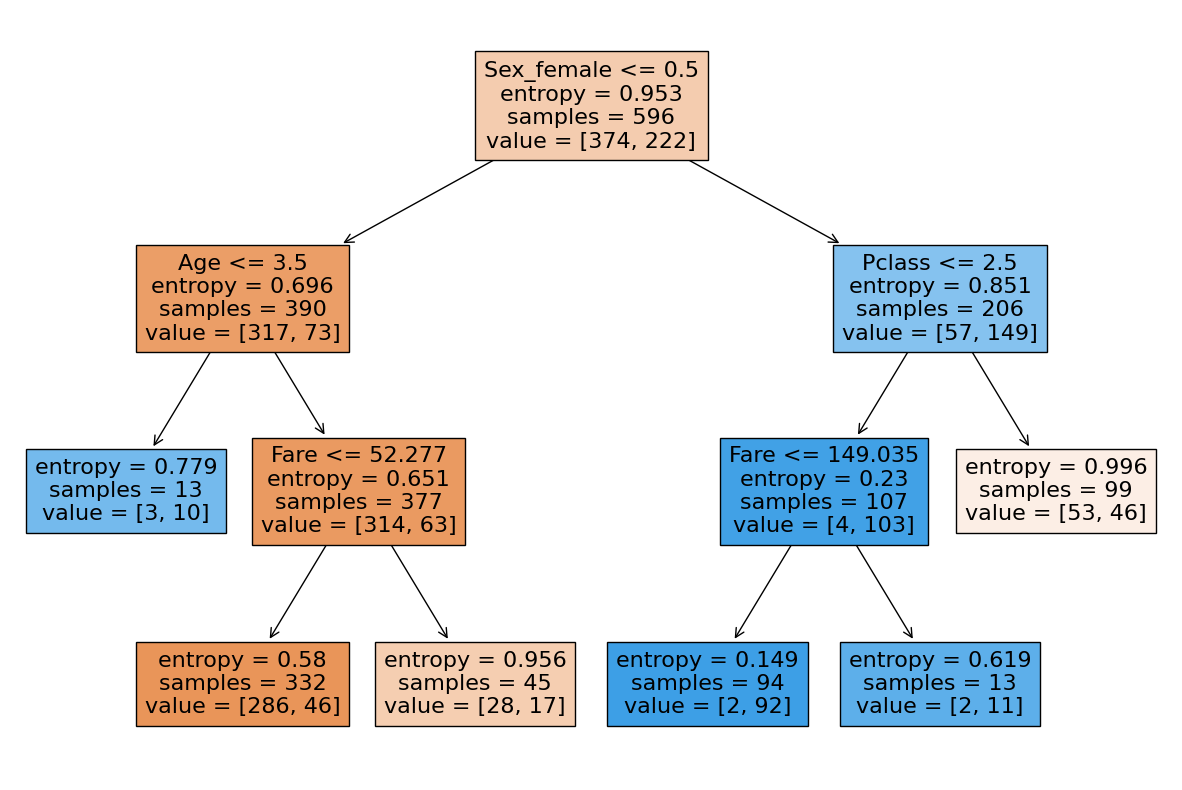

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split

%matplotlib inline

titanic_train = pd.read_csv('/content/titanic.csv')

X = titanic_train.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
y = titanic_train.Survived

X = pd.get_dummies(X) # разбиваем колонки на несколько

X = X.fillna({'Age': X.Age.median()}) # заполняем пропуски

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

clf = tree.DecisionTreeClassifier(criterion='entropy',
                                  max_depth=3,
                                  min_samples_split=100,
                                  min_samples_leaf=10)

clf.fit(X_train, y_train)

plt.figure(figsize=(15, 10))
tree.plot_tree(clf, filled=True, feature_names=list(X))

2. Соотнесите название параметра функции DecisionTreeClassifier и его значение

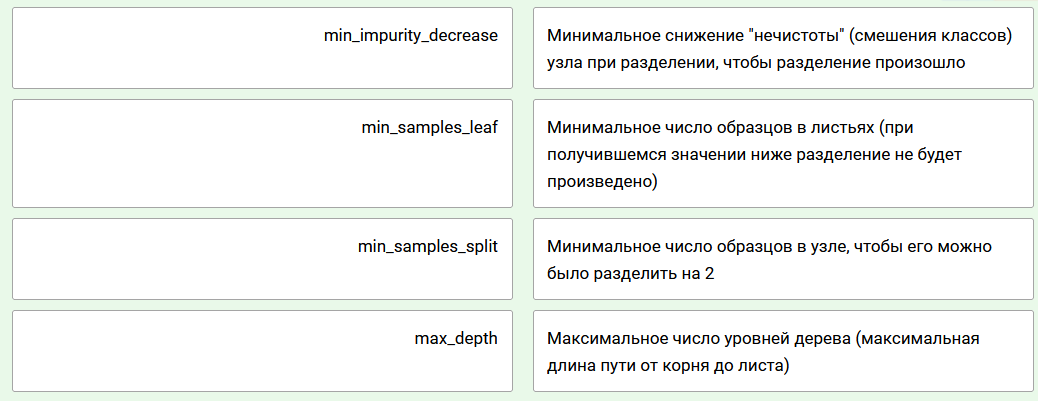

3. Отметьте верные утверждения о влиянии параметров решающего деревья на переобучение

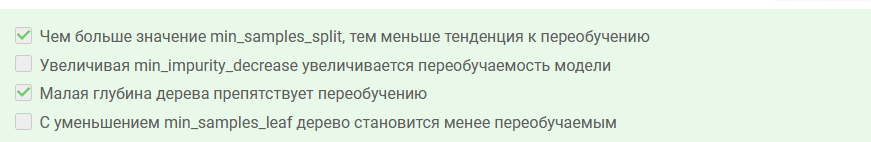

4. Отметьте верные утверждения о влиянии параметров решающего деревья на переобучение

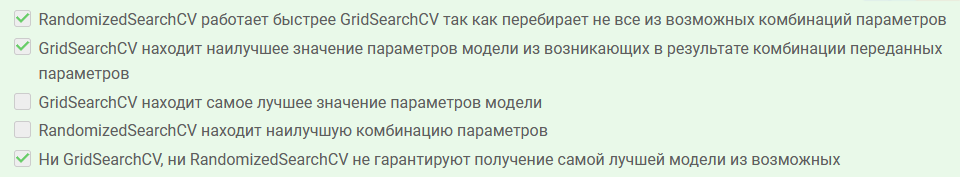

3.2_1 Отметьте верные утверждения о  Random Forest

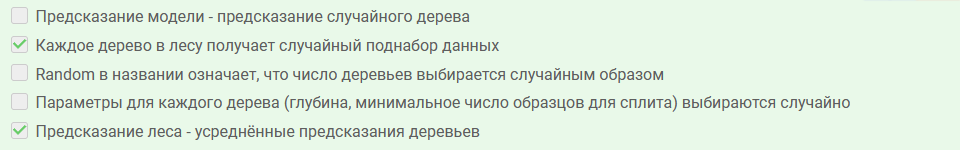

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf_rf = RandomForestClassifier()

In [ ]:
parametrs = {'n_estimators': [10, 20, 30], 'max_depth': [2, 5, 7, 10]}


In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search_cv_clf = GridSearchCV(clf_rf, parametrs, cv = 5)

In [ ]:
grid_search_cv_clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 5, 7, 10],
                         'n_estimators': [10, 20, 30]})

In [ ]:
grid_search_cv_clf.best_params_

{'max_depth': 5, 'n_estimators': 30}

3.2_2 Разминочная задачка - создайте модель RandomForestClassifier с 15 деревьями и максимальной глубиной равной 5 уровням, поместите её в переменную rf. Обучите модель на данных x_train и y_train, предскажите класс для наблюдений в x_test и поместите его в переменную predictions.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=15, max_depth=5)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

In [ ]:
best_clf = grid_search_cv_clf.best_estimator_

In [ ]:
feature_importances = best_clf.feature_importances_

In [ ]:
feature_importances_df = pd.DataFrame({'features': list(X_train),
                                       'feature_importances': feature_importances})

In [ ]:
feature_importances_df.sort_values('feature_importances', ascending=False)

,features,feature_importances
5,Sex_female,0.258220
6,Sex_male,0.229870
4,Fare,0.167108
0,Pclass,0.125205
1,Age,0.101164
2,SibSp,0.038548
3,Parch,0.026692
7,Embarked_C,0.025879
9,Embarked_S,0.023746
8,Embarked_Q,0.003567


3.2_3 Воспользуемся данными о сердечных заболеваниях и обучим на них Random Forest. Постройте график важности переменных для классификации и выберите среди предложенных вариантов наиболее похожий.

В задании присутствует рандом, прогоните обучение случайного леса и построение графика несколько раз, чтобы увидеть изменения в важности фичей (5 самых важных обычно присутствуют в топе, просто в разном порядке).

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/heart-disease.csv')

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [7]:
X_train = df.loc[:,"age":"thal"]
y_train = df["target"]

In [8]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(0)

rf = RandomForestClassifier(10, max_depth=5)
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=10)

In [ ]:
"""
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=15, max_depth=5)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

best_clf = grid_search_cv_clf.best_estimator_

feature_importances = best_clf.feature_importances_

feature_importances_df = pd.DataFrame({'features': list(X_train),
                                       'feature_importances': feature_importances})

feature_importances_df.sort_values('feature_importances', ascending=False)
"""

<Axes: >

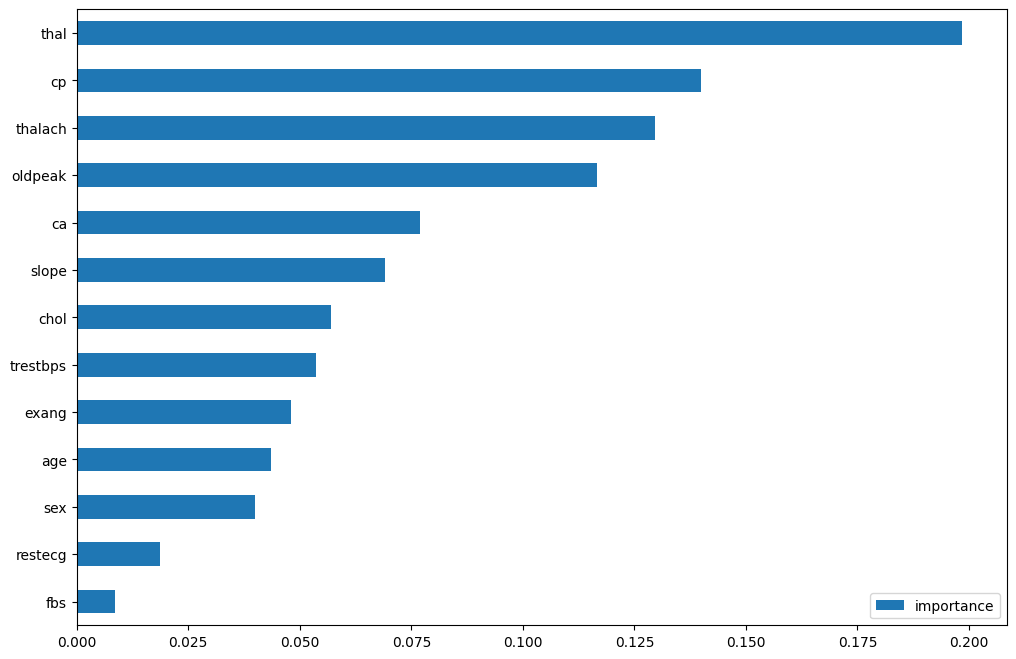

In [11]:
imp = pd.DataFrame(rf.feature_importances_, index=X_train.columns, columns=['importance'])
imp.sort_values('importance').plot(kind='barh', figsize=(12, 8))

In [9]:
import plotly.express as px

# ...


imp = pd.DataFrame(
    rf.feature_importances_,
    index=X_train.columns,
    columns=["importance"]
)

fig = px.histogram(
    imp.sort_values("importance"),
    x=["importance"],
    y=X_train.columns
)

fig.show()

3.5_1

Переберите параметры с помощью GridSearchCV и обучите Random Forest на данных. Передайте в GridSearchCV модель с указанием random_state

RandomForestClassifier(random_state=0)

Параметры для выбора -

    n_estimators: от 10 до 50 с шагом 10
    max_depth: от 1 до 12 с шагом 2
    min_samples_leaf: от 1 до 7
    min_samples_split: от 2 до 9 с шагом 2

Укажите cv=3. Для ускорения расчётов в GridSearchCV можно указать n_jobs=-1, чтобы использовать все процессоры.

Какие параметры Random Forest были отобраны как наилучшие для решения на этих данных?


In [12]:
df = pd.read_csv('https://stepik.org/media/attachments/course/4852/training_mush.csv')
list(df)

['cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-number',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat',
 'class']

In [13]:
X_train = df.loc[:, 'cap-shape' : 'habitat']
y_train = df['class']

In [15]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(0)

In [16]:
clf = RandomForestClassifier(n_jobs = -1)

In [17]:
parametrs = {'n_estimators': range(10, 50, 10), 'max_depth': range(1, 12, 2), 'min_samples_leaf': range(1, 7), 'min_samples_split': (2, 9, 2)}

In [19]:
from sklearn.model_selection import GridSearchCV
grid_search_cv_clf = GridSearchCV(clf, parametrs, cv = 3)

In [20]:
grid_search_cv_clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1),
             param_grid={'max_depth': range(1, 12, 2),
                         'min_samples_leaf': range(1, 7),
                         'min_samples_split': (2, 9, 2),
                         'n_estimators': range(10, 50, 10)})

In [21]:
grid_search_cv_clf.best_params_

{'max_depth': 9,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 10}

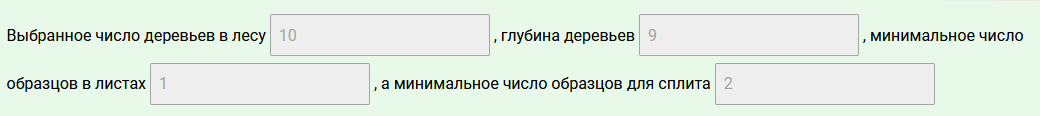

3.5_2 Выберите правильные утверждения о важности фичей для нашего классификатора

In [25]:
rf = RandomForestClassifier(10, max_depth=9, min_samples_leaf = 1, min_samples_split = 2)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, n_estimators=10)

<Axes: >

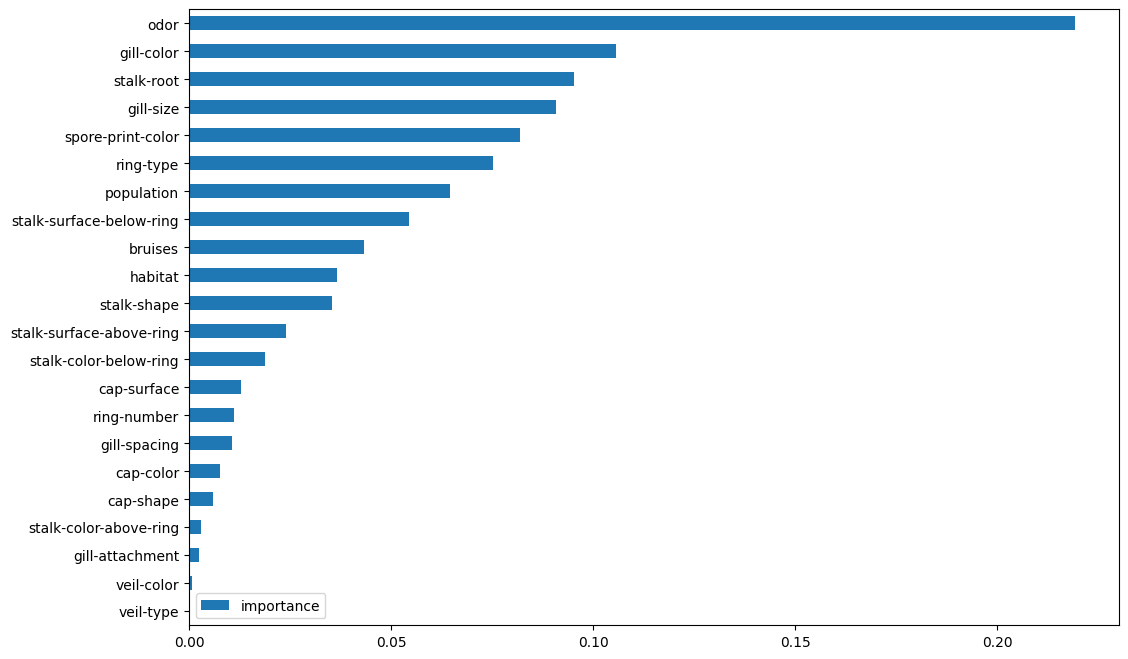

In [26]:
imp = pd.DataFrame(rf.feature_importances_, index=X_train.columns, columns=['importance'])
imp.sort_values('importance').plot(kind='barh', figsize=(12, 8))

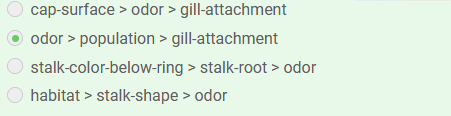


3.5_3

Теперь у нас есть классификатор, определяющий какие грибы съедобные, а какие нет, испробуем его! Предскажите съедобность этих данных грибов и напишите в ответ число несъедобных грибов (класс равен 1).



Заметьте, что для использования этого леса на новых грибах, нам нужно будет заполнить значения параметров гриба, часть из которых определить проще (например, цвет шляпки), а для определения части понадобится специалист-миколог.
То есть в этом случае нам придётся самим экстрагировать признаки из объекта. Для зрительных признаков типа формы, цвета можно использовать более сложную модель (например, свёрточную нейронную сеть) и подавать на вход фотки гриба. И модель сама извлечёт признаки вместо того, чтобы нам описывать самим. Но одной фоткой тут не отделаешься - для определения запаха понадобится ещё детектор


In [27]:
df_test = pd.read_csv('https://stepik.org/media/attachments/course/4852/testing_mush.csv')

In [28]:
df_test

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,3,8,1,3,1,0,0,4,0,...,2,7,7,0,2,1,4,2,3,3
1,5,3,4,1,5,1,0,0,10,1,...,2,6,6,0,2,1,4,3,5,0
2,3,3,4,0,8,1,0,1,0,1,...,2,7,6,0,2,1,0,7,4,4
3,3,2,2,0,7,1,0,1,0,1,...,1,6,7,0,2,1,0,7,4,0
4,3,2,2,0,8,1,0,1,0,1,...,1,6,6,0,2,1,0,7,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026,3,3,2,0,2,1,0,1,0,1,...,1,7,7,0,2,1,0,7,4,2
2027,5,2,8,1,0,1,0,0,10,0,...,2,7,7,0,2,1,4,2,2,1
2028,5,3,3,0,2,1,0,0,3,0,...,1,6,0,0,2,1,2,1,4,4
2029,5,3,3,1,5,1,0,0,9,1,...,2,3,3,0,2,1,4,3,4,0




Данные_грибы = pd.read_csv('https:...')

Тестовые_грибы = pd.read_csv('https:...')

Свойства_грибов = Данные_грибы.drop('Класс', axis=1)

Тестируемые_свойства_грибов = Тестовые_грибы

Съедобность_грибов = Данные_грибы['Класс']

Грибной_лес = RandomForestClassifier(random_state=0)

Параметры =

              {'n_estimators': range(10, 51, 10),

              'max_depth': range(1, 13, 2),

              'min_samples_leaf': range(1, 8),

              'min_samples_split': range(2, 10, 2)}


Поиск _в_ грибном_лесу = GridSearchCV(Грибной_лес, Параметры, cv=3, n_jobs=-1)

Поиск _в_ грибном_лесу.fit(Свойства_грибов, Съедобность_грибов)


Поиск _в_ грибном_лесу.predict(Тестируемые_свойства_грибов).sum()


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://stepik.org/media/attachments/course/4852/training_mush.csv')
df_test = pd.read_csv('https://stepik.org/media/attachments/course/4852/testing_mush.csv')

In [3]:
df

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,2,0,3,1,5,1,0,0,9,1,...,3,7,0,2,1,4,3,5,0,0
1,2,0,4,0,5,1,0,1,10,0,...,7,4,0,2,1,0,7,4,0,1
2,2,0,3,0,2,1,0,0,7,0,...,0,4,0,2,1,2,1,5,1,1
3,0,0,3,0,5,1,1,0,2,0,...,7,7,0,2,2,4,7,3,1,0
4,2,3,3,1,5,1,0,0,10,1,...,3,6,0,2,1,4,2,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6088,2,0,3,0,5,1,1,0,4,1,...,7,7,0,2,1,0,3,3,1,0
6089,3,2,2,0,2,1,0,1,0,1,...,6,7,0,2,1,0,7,4,0,1
6090,5,2,3,0,1,1,0,1,9,0,...,7,7,0,2,1,4,3,4,0,1
6091,3,2,3,0,5,1,1,0,2,0,...,7,7,0,2,2,4,7,3,1,0


In [2]:
df_test

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,3,8,1,3,1,0,0,4,0,...,2,7,7,0,2,1,4,2,3,3
1,5,3,4,1,5,1,0,0,10,1,...,2,6,6,0,2,1,4,3,5,0
2,3,3,4,0,8,1,0,1,0,1,...,2,7,6,0,2,1,0,7,4,4
3,3,2,2,0,7,1,0,1,0,1,...,1,6,7,0,2,1,0,7,4,0
4,3,2,2,0,8,1,0,1,0,1,...,1,6,6,0,2,1,0,7,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026,3,3,2,0,2,1,0,1,0,1,...,1,7,7,0,2,1,0,7,4,2
2027,5,2,8,1,0,1,0,0,10,0,...,2,7,7,0,2,1,4,2,2,1
2028,5,3,3,0,2,1,0,0,3,0,...,1,6,0,0,2,1,2,1,4,4
2029,5,3,3,1,5,1,0,0,9,1,...,2,3,3,0,2,1,4,3,4,0


In [8]:
X_train = df.drop('class', axis = 1)
y_train = df['class']

In [10]:
X_test = df_test

In [11]:
from sklearn.ensemble import RandomForestClassifier
mush_fr = RandomForestClassifier(random_state=0)

In [12]:
params = {'n_estimators': range(10, 51, 10),

          'max_depth': range(1, 13, 2),

          'min_samples_leaf': range(1, 8),

          'min_samples_split': range(2, 10, 2)}

In [14]:
from sklearn.model_selection import GridSearchCV
search_mush_fr = GridSearchCV(mush_fr, params, cv=3, n_jobs=-1)

In [15]:
search_mush_fr.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': range(1, 13, 2),
                         'min_samples_leaf': range(1, 8),
                         'min_samples_split': range(2, 10, 2),
                         'n_estimators': range(10, 51, 10)})

In [16]:
search_mush_fr.predict(X_test).sum()

976

In [ ]:
# Импортируем необходимые модули
# для работы с данными:
import pandas as pd

# для построения леса деревьев решений и обучения моделей:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Считываем файл c данными о съедобности грибов.
mush_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/training_mush.csv')

# Отбросим колонку, которую будем предсказывать.
X = mush_data.drop(['class'], axis=1)
# Создадим переменную, которую будем предсказывать.
y = mush_data['class']

# Создаем модель RandomForestClassifier.
rf = RandomForestClassifier(random_state=0)

# Задаем параметры модели.
parameters = {'n_estimators': range(10, 51, 10), 'max_depth': range(1, 13, 2),
              'min_samples_leaf': range(1,8), 'min_samples_split': range(2,10,2)}

# Обучение Random forest моделей GridSearchCV.
GridSearchCV_clf = GridSearchCV(rf, parameters, cv=3, n_jobs=-1)
GridSearchCV_clf.fit(X, y)

# Определение наилучшего классификатора.
best_clf = GridSearchCV_clf.best_estimator_

# Считываем второй файл c данными о грибах.
mush_data_2 = pd.read_csv('https://stepik.org/media/attachments/course/4852/testing_mush.csv')

# Предсказываем съедобность грибов из второго файла, используя созданный наилучший классификатор.
predictions = best_clf.predict(mush_data_2)

# Определяем число несъедобных грибов (класс равен 1).
print('Число несъедобных грибов = ', predictions.sum())

3.5_4

Создайте confusion matrix по предсказаниям, полученным вами в прошлом уроке и правильным ответам, (воспользуйтесь паролем из предыдущего задания, чтобы открыть их). Выберите из предложенных вариантов правильный


In [17]:
y_true = pd.read_csv('/content/testing_y_mush.csv')

In [19]:
y_pred = search_mush_fr.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, y_pred)

array([[1055,    0],
       [   0,  976]])

<Axes: >

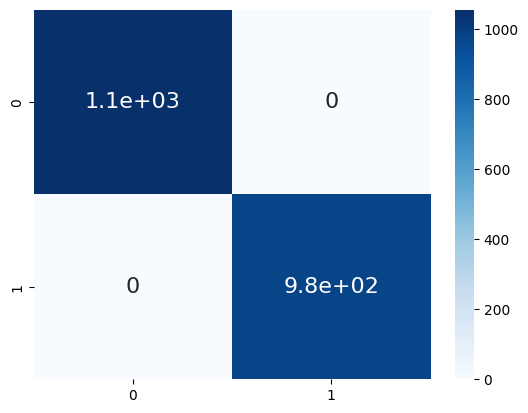

In [22]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True,annot_kws={"size": 16}, cmap="Blues")

In [ ]:
# Импортируем необходимые модули
# для работы с данными:
import pandas as pd
import zipfile

# для построения леса деревьев решений, обучения моделей и построения confusion_matrix:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

# для работы с графикой:
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем размер области для построения графиков.
sns.set(rc={'figure.figsize': (17, 6)})

# Считываем файл c данными о съедобности грибов.
mush_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/training_mush.csv')

# Отбросим колонку, которую будем предсказывать.
X = mush_data.drop(['class'], axis=1)
# Создадим переменную, которую будем предсказывать.
y = mush_data['class']

# Создаем модель RandomForestClassifier.
rf = RandomForestClassifier(random_state=0)

# Задаем параметры модели.
parameters = {'n_estimators': range(10, 51, 10), 'max_depth': range(1, 13, 2),
              'min_samples_leaf': range(1,8), 'min_samples_split': range(2,10,2)}

# Обучение Random forest моделей GridSearchCV.
GridSearchCV_clf = GridSearchCV(rf, parameters, cv=3, n_jobs=-1)
GridSearchCV_clf.fit(X, y)

# Определение наилучшего классификатора.
best_clf = GridSearchCV_clf.best_estimator_

# Считываем второй файл c данными о грибах.
mush_data_2 = pd.read_csv('https://stepik.org/media/attachments/course/4852/testing_mush.csv')

# Предсказываем съедобность грибов из второго файла, используя созданный наилучший классификатор.
predictions = best_clf.predict(mush_data_2)

# Пароль к zip-файлу (появился при решении предыдущей задачи).
password = 'Cool!Move_forward!'

# Считываем правильные данные по съедобности грибов из запароленного архива.
z = zipfile.ZipFile("testing_y_mush.csv.zip")
txtfiles = z.namelist()
y_true = pd.read_csv(z.open(txtfiles[0], "r", pwd=password.encode('cp850', 'replace')))

# Создание confusion matrix по предсказаниям, полученным в прошлом уроке и правильным ответам.
sns.heatmap(confusion_matrix(y_true, predictions), annot=True, cmap="Blues")
plt.show()

3.5_5

Перейдём к следующему датасэту.

На Землю нападают войска жукеров, и в их флоте присутствуют транспортники, истребители и крейсеры. Для борьбы с каждым типом кораблей используется свой вид оружия. Как аналитику из Штаба Обороны, вам поручено разработать модель, предсказывающую какие корабли участвуют в атаке, чтобы успешно отбить нападения на различные области планеты

Данных удалось собрать немного, и предсказывать придётся гораздо больший по объёму массив.

Обучите модель и предскажите классы кораблей для новых поступающих данных. Укажите в ответе через пробел число крейсеров, транспортников и истребителей.

От вашего ответа зависит судьба человечества!


In [23]:
df_bugs = pd.read_csv('https://stepik.org/media/attachments/course/4852/invasion.csv')

In [24]:
X_test = pd.read_csv('https://stepik.org/media/attachments/course/4852/operative_information.csv')

In [25]:
df_bugs

,class,g_reflection,i_reflection,speed,brightness,time_of_observance,volume
0,transport,2.190672,6.716633,62.168208,0.347465,158221,44.932446
1,transport,3.453276,8.995909,62.994707,0.590094,385972,41.568300
2,transport,2.432994,6.938691,62.245807,0.329288,446482,40.123467
3,fighter,6.083763,3.019459,18.474555,0.174738,210125,11.384865
4,fighter,12.876769,2.452950,195.805771,0.150446,23109,11.328806
...,...,...,...,...,...,...,...
495,fighter,9.901731,7.162124,58.095069,0.145065,395762,12.901909
496,transport,3.574132,7.118835,62.928159,0.469670,435926,39.926551
497,fighter,9.186049,4.580781,412.102112,0.108195,299594,12.178203
498,fighter,8.278256,8.353756,268.121561,0.132661,361911,13.905809


In [26]:
X_test

,g_reflection,i_reflection,speed,brightness,time_of_observance,volume
0,7.516543,3.916691,513.954279,0.177247,105908,13.267224
1,4.322988,6.967689,63.752970,0.545922,277855,39.833130
2,4.595724,9.098297,62.233948,0.389201,160662,42.014556
3,2.689675,7.964869,62.475495,0.541081,162092,42.056829
4,8.075576,5.169719,336.441261,0.174757,466853,11.779813
...,...,...,...,...,...,...
1495,11.755466,5.583147,325.069957,0.170644,388400,13.210917
1496,12.220137,4.023177,439.975574,0.163958,195305,13.819358
1497,1.611053,7.864930,65.025106,0.430021,307856,47.369083
1498,7.114131,5.532188,391.178342,0.150117,51590,12.447761


In [32]:
x_train = df_bugs.drop('class', axis = 1)
y_train = df_bugs['class']

In [34]:
# 3. Создаем классификатор случайного леса

clf = RandomForestClassifier()

# 4. Задаем параметры для поиска наилучших параметров

params = { 'max_depth': range(1, 21),

           'min_samples_split': range(1, 14, 2),

           'min_samples_leaf': range(1, 9),

           'max_features': range(2, 11, 2) }

# 5. Создаем объект GridSearchCV с указанными параметрами

search = GridSearchCV(estimator=clf, param_grid=params, cv=3)

# 6. Выполняем поиск наилучших параметров

search.fit(x_train, y_train)

# 7. Получаем лучшую модель после выполнения GridSearchCV

best_clf = search.best_estimator_

# 8. Считываем operative_information.csv

#operative_info = pd.read_csv('operative_information.csv')

# 9. Выполняем предсказания на operative_information

y_pred = best_clf.predict(X_test)

# 10. Выполняем подсчет количества кораблей каждого класса

ship_counts = pd.Series(y_pred).value_counts()

# Выводим результаты

print("Число крейсеров:", ship_counts['cruiser'])

print("Число транспортников:", ship_counts['transport'])

print("Число истребителей:", ship_counts['fighter'])

KeyboardInterrupt: 

In [ ]:
# Подсчёт классов в предсказаниях:
pd.Series(y_pred).value_counts()

In [37]:
clf = RandomForestClassifier()
clf.fit(x_train, y_train)
y_pred = clf.predict(X_test)
pd.Series(y_pred).value_counts()

fighter      675
transport    595
cruiser      230
Name: count, dtype: int64

In [ ]:
# Импорт библиотек
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Загрузка данных
df = pd.read_csv('https://stepik.org/media/attachments/course/4852/invasion.csv')
X_test = pd.read_csv('https://stepik.org/media/attachments/course/4852/operative_information.csv')
print('info()', '\033[90m'), print(df.info(), '\033[0m')
print('head()', '\033[90m'), print(df.head(), '\033[0m')

# Создание выборок
X = df.drop(['class'], axis=1)
y = df['class']

# Разбивка выборок
X_train, y_train = X, y

# Создаем модель
rf_clf = RandomForestClassifier(random_state=0, n_jobs=-1)

# Тренируем модель
rf_clf.fit(X_train, y_train)

# Предсказание на тестовых данных с записью результата в формате pd.Series
y_pred = pd.Series(rf_clf.predict(X_test), name='class')

# Подсчет значений в предсказанных данных
y_pred_values = y_pred.value_counts()
print('value_counts()', '\033[90m'), print(y_pred.value_counts(), '\033[0m')

print(f"Число крейсеров, транспортников и истребителей: {y_pred_values[2]} {y_pred_values[1]} {y_pred_values[0]}")

In [ ]:
# Импортируем библиотеку pandas
import pandas as pd

# Сохраняем URL тренировочного набора данных (с метками)
url_train = 'https://stepik.org/media/attachments/course/4852/invasion.csv'

# Сохраняем URL тестового набора данных (без меток)
url_test = 'https://stepik.org/media/attachments/course/4852/operative_information.csv'

# Создаём DataFrame тренировочного набора данных
transport_train = pd.read_csv(url_train)
transport_train.head(1)

# Создаём DataFrame тестового набора данных
transport_test = pd.read_csv(url_test)
transport_test.head(1)

# Переводим номинативную переменную в количественную
# {'transport': 0, 'fighter': 1, 'cruiser': 2}
transport_train['class'] = pd.factorize(transport_train['class'])[0]

# Создадим переменную для данных для тренировки, исключив из неё вектор предсказаний
X_train = transport_train.drop('class', axis=1)
# Создадим переменную для предсказания тренировочных данных
y_train = transport_train['class']

# Смотрим на уникальные значения, которые необходимо предсказать
y_train.unique()

# Смотрим на размеры тренировочной и тестовой выборки
(transport_train.shape, transport_test.shape)

# Из библиотеки sklearn импортируем модель случайного леса RandomForestClassifier,
# а также поиск лучшей модели GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Создаём экземпляр модели случайного леса
rf_clf = RandomForestClassifier()

# Создаём параметры для перебора деревьев:
# Количество деревьев, максимальная глубина, минимальное количество в листе, минимальное количество для разбиения.
parametrs = {'n_estimators': range(10, 51, 10),
             'max_depth': range(1, 11, 2),
             'min_samples_leaf': range(5, 11),
             'min_samples_split': range(10, 21, 2)}

# Создаём экземпляр класса для лучшей модели с созданным классификатором и заданными параметрами
# cv - количество разбиений для кроссвалидации
# n_jobs=-1 - задействуем все процессоры для ускорения скорости обучения
# verbose=1 - смотрим сколько всего моделей будет построено и сколько тренировок будет проведено
grid_search_clf = GridSearchCV(rf_clf, parametrs, cv = 3, n_jobs=-1, verbose=1)

# Ищем лучшую модель на тренировочных данных
grid_search_clf.fit(X_train, y_train)

# Заглядываем в параметры для лучшей модели
grid_search_clf.best_params_

# Создаём экземпляр лучшей модели
best_clf = grid_search_clf.best_estimator_

# Предсказываем результаты на тестовых данных и сохраняем их в pd.Series
y_pred = pd.Series(best_clf.predict(transport_test))

# Подсчитываем количество крейсеров, транспортников и истребителей
# {'transport': 0, 'fighter': 1, 'cruiser': 2}
y_pred.value_counts()

3.5_7 Какая переменная оказалась самой важной для классифицирования кораблей?

<Axes: >

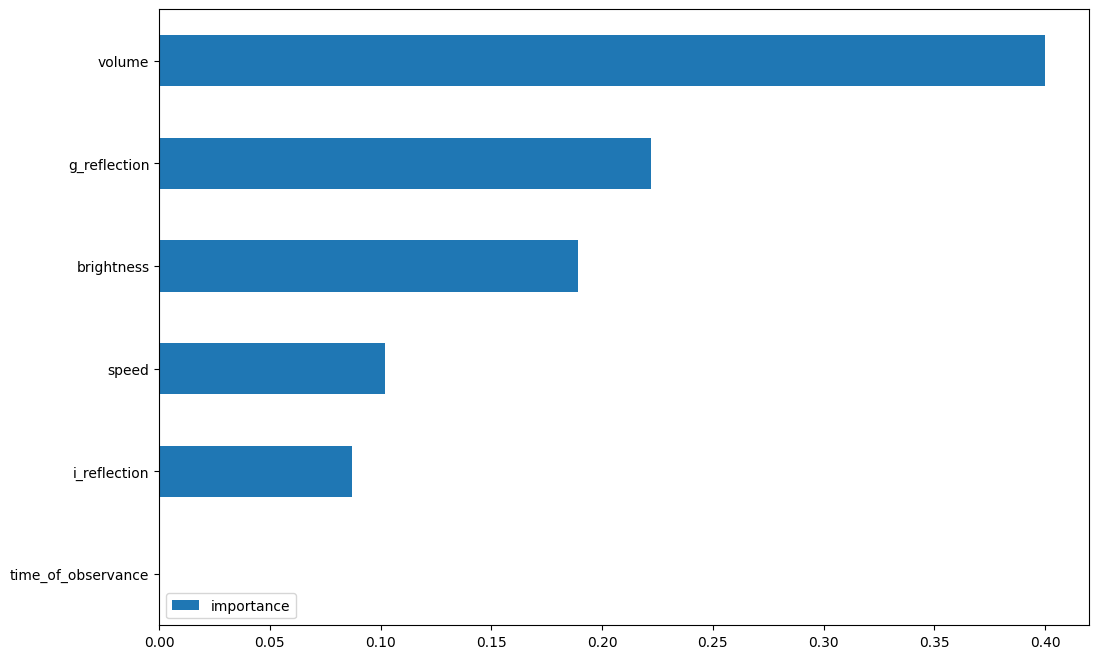

In [40]:
imp = pd.DataFrame(clf.feature_importances_, index=x_train.columns, columns=['importance'])
imp.sort_values('importance').plot(kind='barh', figsize=(12, 8))

3.5_8

Благодаря вашим стараниям войска захватчиков были разгромлены, но война ещё не окончена! Вас повысили и перевели на новое направление (новые должности - новые задачи) - теперь нужно выявлять опасные регионы космоса, где могут находиться жукеры.

Проанализируйте имеющиеся данные об опасности разных регионов космоса и укажите наиболее вероятные причины угрозы


In [41]:
df_new = pd.read_csv('https://stepik.org/media/attachments/course/4852/space_can_be_a_dangerous_place.csv')

In [42]:
df_new

,r,phi,peradventure_index,dustiness,black_hole_is_near,buggers_were_noticed,nearby_system_has_planemo,dangerous
0,169.1,138.0,22.3212,0.706285,0,1,1,1
1,11.1,148.0,1.4652,-0.410512,1,1,1,1
2,274.6,201.0,36.2472,0.756457,1,1,1,1
3,172.8,173.0,22.8096,0.035221,1,1,1,1
4,223.3,222.0,29.4756,0.197271,0,1,1,1
...,...,...,...,...,...,...,...,...
99995,301.7,249.0,39.8244,0.397064,0,1,1,1
99996,194.0,350.0,25.6080,-1.062202,0,1,1,1
99997,201.4,112.0,26.5848,1.571040,0,1,1,1
99998,7.8,115.0,1.0296,-1.206575,0,1,1,1


In [45]:
x_train = df_new.drop('dangerous', axis = 1)
y_train = df_new['dangerous']

In [46]:
clf = RandomForestClassifier()
clf.fit(x_train, y_train)


RandomForestClassifier()

<Axes: >

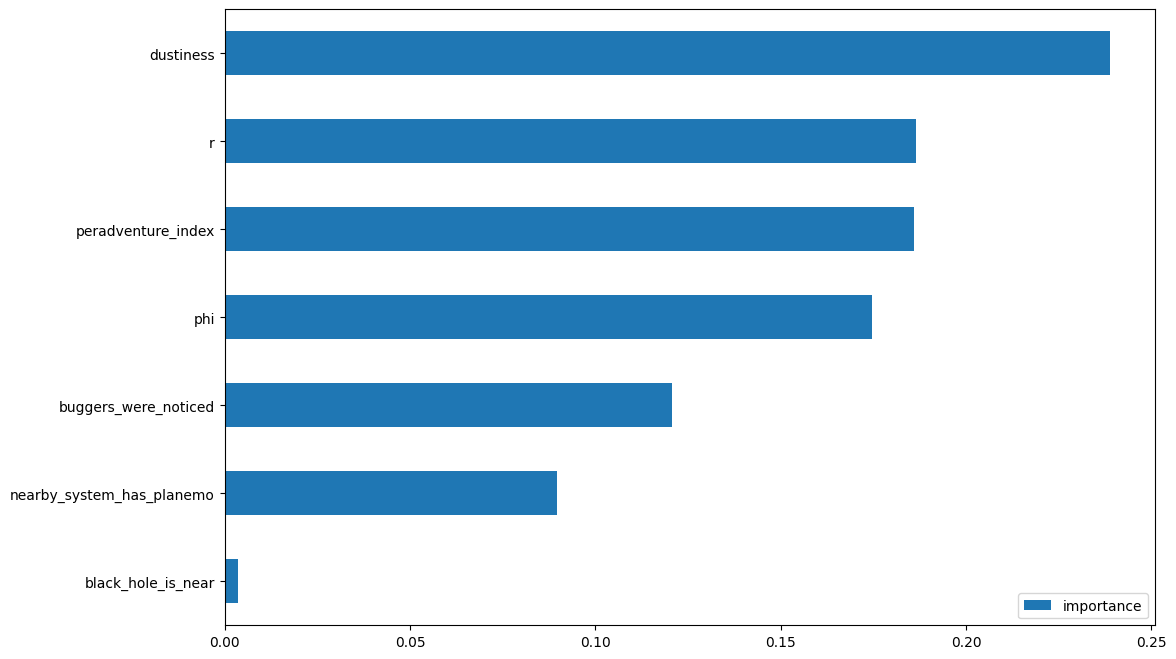

In [47]:
imp = pd.DataFrame(clf.feature_importances_, index=x_train.columns, columns=['importance'])
imp.sort_values('importance').plot(kind='barh', figsize=(12, 8))

<Axes: >

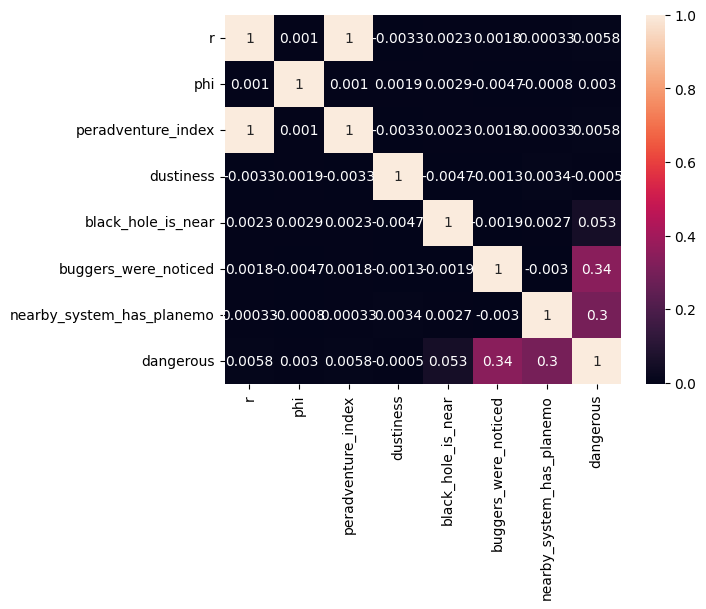

In [49]:
 sns.heatmap(df_new.corr(), annot=True)

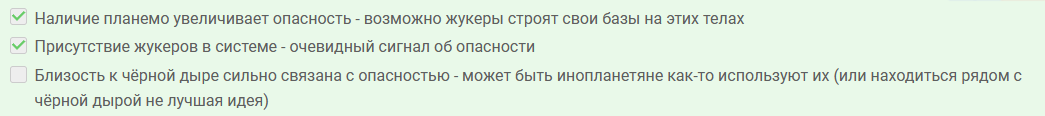

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split

%matplotlib inline

<Axes: >

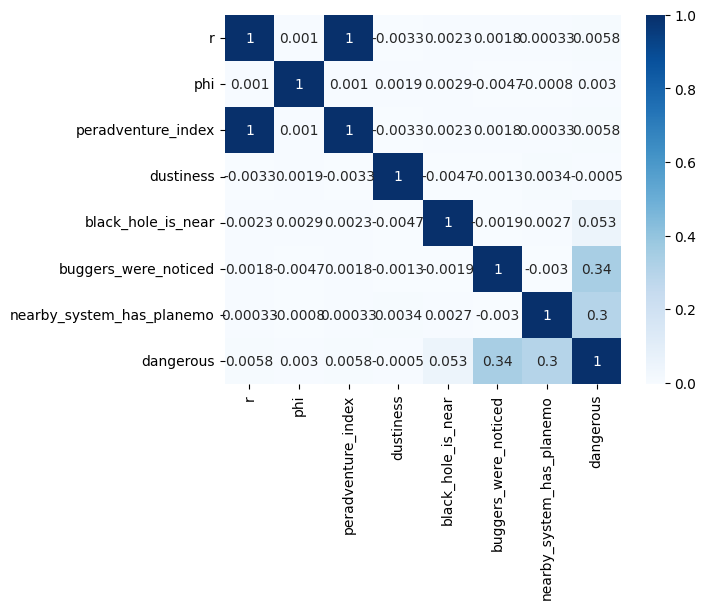

In [53]:
sns.heatmap(df_new.corr(), annot=True, cmap=plt.cm.Blues)

In [55]:
#'Строк с данными : ', len(df_train))
print('Влияние жуков : ', len(df_new.query('dangerous > 0 & buggers_were_noticed > 0')) / len(df_new) * 100, '%')
print('Влияние планемо : ', len(df_new.query('dangerous > 0 & nearby_system_has_planemo > 0')) / len(df_new) * 100, '%')
print('Влияние близости к черной дыре : ', len(df_new.query('dangerous > 0 & black_hole_is_near > 0')) / len(df_new) * 100, '%')

Влияние жуков :  86.5 %
Влияние планемо :  90.202 %
Влияние близости к черной дыре :  10.414 %


In [57]:
df_new[['black_hole_is_near', 'buggers_were_noticed', 'nearby_system_has_planemo', 'dangerous']].corr()

,black_hole_is_near,buggers_were_noticed,nearby_system_has_planemo,dangerous
black_hole_is_near,1.000000,-0.001874,0.002661,0.052968
buggers_were_noticed,-0.001874,1.000000,-0.003031,0.344469
nearby_system_has_planemo,0.002661,-0.003031,1.000000,0.299508
dangerous,0.052968,0.344469,0.299508,1.000000


<Axes: >

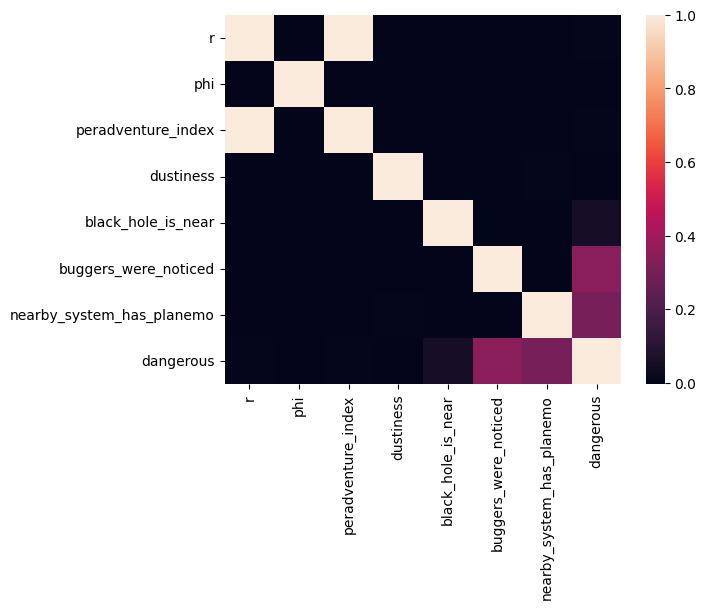

In [59]:
sns.heatmap(df_new.corr())

<Axes: >

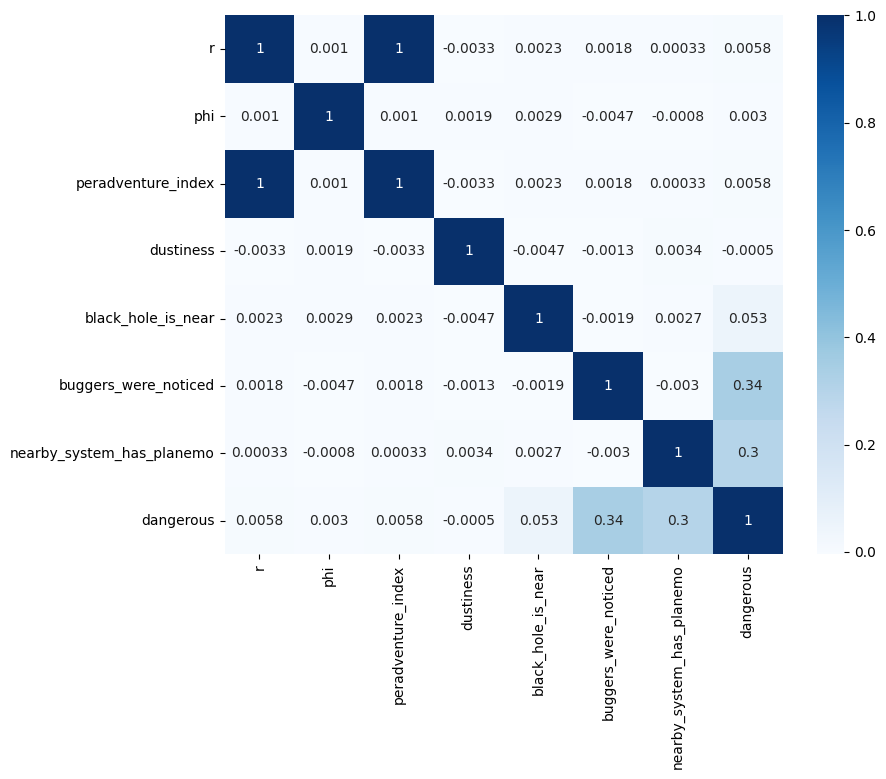

In [60]:
plt.figure(figsize=(9,7))
sns.heatmap(df_new.corr()
            ,cmap ='Blues'
            ,annot = True)